# OCR engine benchmark — Indian cheque-back **account-number** extraction

Compare several **lightweight, offline** OCR engines on the *back* of Indian bank cheques and
decide, with a calibrated **overall confidence**, what the recipient account number is.

**Ground truth** is the image filename (e.g. `50200100550851.png` → `50200100550851`).

### Why this is hard (from the real samples)
- The account number is **handwritten**, sometimes preceded by *"A/c No"*, and in one sample the
  scan is **rotated ~180°**.
- Lots of **distractor numbers**: the printed MICR band, cheque numbers, the IFSC line
  (`IFSC Code: HDFC0000000`), bank-stamp employee codes.
- **Diagonal watermarks** (`s77051`, dates, times) and black scan bars.

### Engines compared (all run on CPU, offline after a one-time cache) — classic → modern SOTA
| Engine | Year | Kind | Handwriting | Confidence | Weight |
|---|---|---|---|---|---|
| **Tesseract** (pytesseract) | 2006+ | classic CV | weak | per-word (0–100) | tiny (system binary) |
| **RapidOCR / PP-OCRv4** | 2023 | PP-OCR → ONNX | weak–moderate | per-line [0,1] | ~15 MB, no torch |
| **EasyOCR** | 2020 | CRAFT+CRNN (torch) | moderate | per-line [0,1] | ~64 MB models |
| **TrOCR-handwritten** | 2021 | transformer (torch) | strong | token-prob derived | ~1.4 GB (on crops) |
| **PP-OCRv5** (new RapidOCR) | **2025** | PP-OCRv5 → ONNX | **much improved** | per-line [0,1] | small, no torch |
| **GOT-OCR 2.0** | **2024** | 580M unified OCR transformer | strong | token-prob derived | ~1.4 GB |
| **Qwen2.5-VL-3B** | **2025** | frontier vision-language model | **strong** | token-prob derived | ~7 GB (full page + crop) |

*(SOTA reference, June 2026: PaddleOCR-VL-0.9B leads OmniDocBench 96.3; dots.ocr 1.7B, DeepSeek-OCR-3B,
Nanonets-OCR2-3B, OlmOCR-2-7B are the frontier — all VLM-based single-pass OCR. We include the
strongest that install + run **offline on CPU** here.)*

### The key idea — overall confidence ≠ model confidence
Printed-text engines report **high** confidence on the clean printed MICR/IFSC digits and
**low/erratic** confidence on the actual handwriting — so ranking by model score alone picks a
distractor. We instead blend **cross-engine agreement + structural validity + region prior +
digit stability**, with model confidence as just one down-weighted input, and show the blend
separates correct from incorrect far better than raw model confidence.

In [1]:
# --- Config & offline switches -------------------------------------------------
import os, sys
# Run fully offline once weights are cached (EasyOCR ~/.EasyOCR, HF hub cache).
os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

from pathlib import Path
CHEQUE_DIR = Path("../exampleCheques").resolve()
assert CHEQUE_DIR.is_dir(), f"cheque dir not found: {CHEQUE_DIR}"
IMAGES = sorted(CHEQUE_DIR.glob("*.png"))

# Account-number shape prior (configurable so it generalises beyond these 14-digit HDFC samples).
ACCT_TARGET_LEN = 14
ACCT_MIN_LEN, ACCT_MAX_LEN = 10, 18

# TrOCR is the heavy specialist; keep it on by default per "download if required, run offline".
USE_TROCR = True
TROCR_MODEL = "microsoft/trocr-base-handwritten"

# --- Modern (2025-2026) SOTA engines ------------------------------------------
USE_PPOCRV5 = True                              # PP-OCRv5 via the new `rapidocr` pkg (ONNX, offline, no torch)
USE_GOT = True                                  # GOT-OCR 2.0 — 580M unified end-to-end OCR transformer
GOT_MODEL = "stepfun-ai/GOT-OCR-2.0-hf"
USE_QWEN = True                                 # Qwen2.5-VL-3B — frontier vision-language model
QWEN_MODEL = "Qwen/Qwen2.5-VL-3B-Instruct"
VLM_PROMPT = ("This is the back of an Indian bank cheque. Read the handwritten recipient bank "
              "ACCOUNT NUMBER (a long run of digits, sometimes labelled 'A/c No'). "
              "Reply with ONLY the digits — no spaces, no words.")
VLM_MAX_NEW_TOKENS = 24
GOT_MAX_SIDE = 1280                             # GOT is cheap (~18s/img): read full page + crops
VLM_CROPS = 1                                   # handwriting-band crops for GOT (besides full page)
# MEASURED: Qwen2.5-VL-3B fp32 on this CPU is ~1000s on a full page (~100x slower than PP-OCRv5)
# and read the MICR line instead of the account number. So we run it on ONE tight band crop only
# (far fewer vision tokens) to keep it tractable. On a GPU you'd run it on the full page.
QWEN_MAX_SIDE = 900

def truth_of(p: Path) -> str:
    # Ground truth = digits in the filename stem.
    return "".join(ch for ch in p.stem if ch.isdigit())

print("images:", [p.name for p in IMAGES])
print("truths:", {p.name: truth_of(p) for p in IMAGES})

images: ['00132990000025.png', '50200068022791.png', '50200100550851.png']
truths: {'00132990000025.png': '00132990000025', '50200068022791.png': '50200068022791', '50200100550851.png': '50200100550851'}


In [2]:
# --- Imports & engine availability --------------------------------------------
import re, math, statistics, time, warnings
warnings.filterwarnings("ignore")
import numpy as np
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

AVAIL = {}
try:
    import pytesseract
    from pytesseract import Output as _TessOut
    _ = pytesseract.get_tesseract_version()
    AVAIL["tesseract"] = True
except Exception as e:
    AVAIL["tesseract"] = False; print("tesseract unavailable:", e)

try:
    from rapidocr_onnxruntime import RapidOCR
    _RAPID = RapidOCR()
    AVAIL["rapidocr"] = True
except Exception as e:
    AVAIL["rapidocr"] = False; print("rapidocr unavailable:", e)

try:
    import easyocr
    _EASY = easyocr.Reader(["en"], gpu=False, verbose=False)
    AVAIL["easyocr"] = True
except Exception as e:
    AVAIL["easyocr"] = False; print("easyocr unavailable:", e)

_TROCR = None
if USE_TROCR:
    try:
        import torch
        from transformers import TrOCRProcessor, VisionEncoderDecoderModel
        _TPROC = TrOCRProcessor.from_pretrained(TROCR_MODEL, local_files_only=True)
        _TMODEL = VisionEncoderDecoderModel.from_pretrained(TROCR_MODEL, local_files_only=True)
        _TMODEL.eval()
        _TROCR = True
        AVAIL["trocr"] = True
    except Exception as e:
        AVAIL["trocr"] = False; print("trocr unavailable:", e)
else:
    AVAIL["trocr"] = False

# --- modern engines ---
_PP5 = None
if USE_PPOCRV5:
    try:
        from rapidocr import RapidOCR as _RapidV5     # new unified pkg defaults to PP-OCRv5 ONNX
        _PP5 = _RapidV5()
        AVAIL["ppocrv5"] = True
    except Exception as e:
        AVAIL["ppocrv5"] = False; print("ppocrv5 unavailable:", e)
else:
    AVAIL["ppocrv5"] = False

if USE_GOT:
    try:
        import torch
        from transformers import AutoProcessor as _AutoProc, AutoModelForImageTextToText as _AutoITT
        _GOTP = _AutoProc.from_pretrained(GOT_MODEL, local_files_only=True)
        _GOTM = _AutoITT.from_pretrained(GOT_MODEL, dtype=torch.float32, local_files_only=True).eval()
        AVAIL["got"] = True
    except Exception as e:
        AVAIL["got"] = False; print("got unavailable:", e)
else:
    AVAIL["got"] = False

if USE_QWEN:
    try:
        import torch
        from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor as _QAutoProc
        _QM = Qwen2_5_VLForConditionalGeneration.from_pretrained(
            QWEN_MODEL, dtype=torch.float32, local_files_only=True).eval()
        _QP = _QAutoProc.from_pretrained(QWEN_MODEL, local_files_only=True)
        AVAIL["qwen"] = True
    except Exception as e:
        AVAIL["qwen"] = False; print("qwen unavailable:", e)
else:
    AVAIL["qwen"] = False

ENGINES = [k for k in ("tesseract","rapidocr","ppocrv5","easyocr","trocr","got","qwen") if AVAIL.get(k)]
print("available engines:", ENGINES)

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[INFO] 2026-06-23 23:10:09,720 [RapidOCR] base.py:23: Using engine_name: onnxruntime


[INFO] 2026-06-23 23:10:09,729 [RapidOCR] download_file.py:60: File exists and is valid: /Users/soubhikghosh/Codes/Aakaar/docs/ocr-bench/.venv/lib/python3.13/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx


[INFO] 2026-06-23 23:10:09,730 [RapidOCR] main.py:63: Using /Users/soubhikghosh/Codes/Aakaar/docs/ocr-bench/.venv/lib/python3.13/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx


...

[INFO] 2026-06-23 23:10:09,783 [RapidOCR] main.py:63: Using /Users/soubhikghosh/Codes/Aakaar/docs/ocr-bench/.venv/lib/python3.13/site-packages/rapidocr/models/PP-OCRv6_rec_small.onnx


Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

[ERROR] `loss` is part of Qwen2_5_VLCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /Users/soubhikghosh/Codes/Aakaar/docs/ocr-bench/.venv/lib/python3.13/site-packages/transformers/models/qwen2_5_vl/modeling_qwen2_5_vl.py.
[ERROR] `logits` is part of Qwen2_5_VLCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /Users/soubhikghosh/Codes/Aakaar/docs/ocr-bench/.venv/lib/python3.13/site-packages/transformers/models/qwen2_5_vl/modeling_qwen2_5_vl.py.


Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

available engines: ['tesseract', 'rapidocr', 'ppocrv5', 'easyocr', 'trocr', 'got', 'qwen']


In [3]:
# --- Preprocessing: load, downscale, variants ----------------------------------
MAX_SIDE = 2000

def load_rgb(path: Path) -> Image.Image:
    img = Image.open(path).convert("RGB")          # drop alpha (RGBA -> RGB)
    if max(img.size) > MAX_SIDE:
        s = MAX_SIDE / max(img.size)
        img = img.resize((round(img.width * s), round(img.height * s)))
    return img

def otsu_binarize(gray: np.ndarray) -> np.ndarray:
    # Pure-numpy Otsu; drops faint diagonal watermarks while keeping dark digits.
    hist, _ = np.histogram(gray, bins=256, range=(0, 256))
    total = gray.size; sumv = np.dot(np.arange(256), hist)
    sumB = wB = 0.0; best_t, best_var = 127, -1.0
    for t in range(256):
        wB += hist[t]
        if wB == 0: continue
        wF = total - wB
        if wF == 0: break
        sumB += t * hist[t]
        mB = sumB / wB; mF = (sumv - sumB) / wF
        var = wB * wF * (mB - mF) ** 2
        if var > best_var: best_var, best_t = var, t
    return (gray > best_t).astype(np.uint8) * 255

def variants(img: Image.Image) -> dict[str, np.ndarray]:
    # 3-channel uint8 arrays the engines accept, at 0 deg and 180 deg, plus an Otsu variant.
    rgb = np.array(img)
    gray = np.array(img.convert("L"))
    otsu = np.stack([otsu_binarize(gray)] * 3, axis=-1)
    out = {
        "rgb@0": rgb,
        "otsu@0": otsu,
        "rgb@180": np.ascontiguousarray(np.rot90(rgb, 2)),
    }
    return out

In [4]:
# --- Text / digit utilities ----------------------------------------------------
_CONF = {"O": "0", "Q": "0", "D": "0", "I": "1", "L": "1", "|": "1",
         "Z": "2", "S": "5", "B": "8", "G": "6", "T": "7", "A": "4", "g": "9", "q": "9"}

def normalize_digits(text: str) -> tuple[str, int]:
    # Map common OCR letter<->digit confusions; return (normalized, num_fixes).
    fixes, out = 0, []
    for ch in text.upper():
        if ch.isdigit(): out.append(ch)
        elif ch in _CONF: out.append(_CONF[ch]); fixes += 1
        else: out.append(ch)
    return "".join(out), fixes

DIGIT_RUN = re.compile(r"(?<!\d)\d{%d,%d}(?!\d)" % (ACCT_MIN_LEN, ACCT_MAX_LEN))
DISTRACTOR_WORDS = ("IFSC", "HDFC", "EMP", "CODE", "DESIGNATION", "MANAGER", "BANKER", "SALES")
ANCHOR_WORDS = ("A/C", "AC NO", "A/C NO", "ALC", "ACCOUNT")

def levenshtein(a: str, b: str) -> int:
    if a == b: return 0
    if not a: return len(b)
    if not b: return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[-1] + 1, prev[j-1] + (ca != cb)))
        prev = cur
    return prev[-1]

def cer(pred: str, truth: str) -> float:
    return levenshtein(pred, truth) / max(1, len(truth))

In [5]:
# --- Engine wrappers: each returns a list of detections -----------------------
# detection = {engine, text, conf(0..1), box(x0,y0,x1,y1), variant, line_text}

def _poly_to_box(poly):
    xs = [p[0] for p in poly]; ys = [p[1] for p in poly]
    return (float(min(xs)), float(min(ys)), float(max(xs)), float(max(ys)))

def run_tesseract(arr, variant):
    dets = []
    cfg = "--oem 3 --psm 11"
    d = pytesseract.image_to_data(arr, config=cfg, output_type=_TessOut.DICT)
    n = len(d["text"])
    # group words into lines for gluing split digits
    lines = {}
    for i in range(n):
        txt = d["text"][i].strip()
        if not txt: continue
        conf = float(d["conf"][i]); conf = conf/100 if conf >= 0 else 0.0
        box = (float(d["left"][i]), float(d["top"][i]),
               float(d["left"][i]+d["width"][i]), float(d["top"][i]+d["height"][i]))
        key = (d["block_num"][i], d["par_num"][i], d["line_num"][i])
        lines.setdefault(key, []).append((box[0], txt, conf, box))
        dets.append({"engine":"tesseract","text":txt,"conf":conf,"box":box,
                     "variant":variant,"line_text":txt})
    for key, ws in lines.items():
        ws.sort()
        line_txt = " ".join(w[1] for w in ws)
        conf = float(np.mean([w[2] for w in ws]))
        xs0=[w[3][0] for w in ws]; ys0=[w[3][1] for w in ws]; xs1=[w[3][2] for w in ws]; ys1=[w[3][3] for w in ws]
        dets.append({"engine":"tesseract","text":line_txt,"conf":conf,
                     "box":(min(xs0),min(ys0),max(xs1),max(ys1)),"variant":variant,"line_text":line_txt})
    return dets

def run_rapidocr(arr, variant):
    res, _ = _RAPID(arr)
    dets = []
    for item in (res or []):
        poly, txt, score = item[0], item[1], float(item[2])
        dets.append({"engine":"rapidocr","text":txt,"conf":score,"box":_poly_to_box(poly),
                     "variant":variant,"line_text":txt})
    return dets

def run_easyocr(arr, variant):
    dets = []
    for poly, txt, score in _EASY.readtext(arr, detail=1, paragraph=False):
        dets.append({"engine":"easyocr","text":txt,"conf":float(score),"box":_poly_to_box(poly),
                     "variant":variant,"line_text":txt})
    return dets

def trocr_read(pil_crop):
    import torch
    pv = _TPROC(images=pil_crop.convert("RGB"), return_tensors="pt").pixel_values
    with torch.no_grad():
        gen = _TMODEL.generate(pv, max_new_tokens=40, output_scores=True,
                               return_dict_in_generate=True)
    text = _TPROC.batch_decode(gen.sequences, skip_special_tokens=True)[0]
    # confidence = exp(mean log P(token)) over generated tokens
    try:
        ts = _TMODEL.compute_transition_scores(gen.sequences, gen.scores, normalize_logits=True)
        conf = float(torch.exp(ts.mean()).item()) if ts.numel() else 0.0
    except Exception:
        conf = 0.0
    return text, conf

In [6]:
# --- Modern engine wrappers (PP-OCRv5 / GOT-OCR 2.0 / Qwen2.5-VL) --------------
def run_ppocrv5(arr, variant):
    out = _PP5(arr)
    dets = []
    txts = getattr(out, "txts", None)        # new rapidocr object API
    if txts is not None:
        boxes = getattr(out, "boxes", None); scores = getattr(out, "scores", None)
        for i, txt in enumerate(txts or []):
            score = float(scores[i]) if scores is not None and i < len(scores) else 0.0
            box = _poly_to_box(boxes[i]) if boxes is not None and i < len(boxes) else (0.,0.,0.,0.)
            dets.append({"engine":"ppocrv5","text":str(txt),"conf":score,"box":box,
                         "variant":variant,"line_text":str(txt)})
        return dets
    res = out[0] if isinstance(out, tuple) else out      # fallback: list-of-[box,text,score]
    for item in (res or []):
        poly, txt, score = item[0], item[1], float(item[2])
        dets.append({"engine":"ppocrv5","text":txt,"conf":score,"box":_poly_to_box(poly),
                     "variant":variant,"line_text":txt})
    return dets

def _gen_text_conf(model, inputs, n_prompt):
    import torch
    with torch.no_grad():
        gen = model.generate(**inputs, max_new_tokens=VLM_MAX_NEW_TOKENS, do_sample=False,
                             output_scores=True, return_dict_in_generate=True)
    seq = gen.sequences
    new = seq[0, n_prompt:]
    try:
        ts = model.compute_transition_scores(seq, gen.scores, normalize_logits=True)
        conf = float(torch.exp(ts.mean()).item()) if ts.numel() else 0.0
    except Exception:
        conf = 0.0
    return new, conf

def got_read(pil):
    inp = _GOTP(pil.convert("RGB"), return_tensors="pt")
    n = inp["input_ids"].shape[1]
    new, conf = _gen_text_conf(_GOTM, inp, n)
    return _GOTP.decode(new, skip_special_tokens=True), conf

def qwen_read(pil):
    msg = [{"role":"user","content":[{"type":"image","image":pil},{"type":"text","text":VLM_PROMPT}]}]
    chat = _QP.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)
    inp = _QP(text=[chat], images=[pil], return_tensors="pt")
    n = inp.input_ids.shape[1]
    new, conf = _gen_text_conf(_QM, inp, n)
    return _QP.batch_decode(new.unsqueeze(0), skip_special_tokens=True)[0], conf

def vlm_downscale(img, mx):
    if max(img.size) <= mx: return img
    s = mx / max(img.size)
    return img.resize((round(img.width*s), round(img.height*s)))

def account_band(img):
    # Central band above the MICR/IFSC line where the handwritten account number usually sits.
    W_, H_ = img.size
    return img.crop((int(0.03*W_), int(0.12*H_), int(0.97*W_), int(0.52*H_)))

In [7]:
# --- Per-image candidate extraction -------------------------------------------
def line_glue_candidates(dets):
    # Reconstruct lines per engine across a variant by y-band, glue digit tokens L->R,
    # then pull digit runs. Captures handwritten digits emitted as separate tokens.
    out = []
    by_engine = {}
    for d in dets:
        by_engine.setdefault((d["engine"], d["variant"]), []).append(d)
    for _, group in by_engine.items():
        group = sorted(group, key=lambda d: (round((d["box"][1]+d["box"][3])/2/25), d["box"][0]))
        bands = {}
        for d in group:
            yc = round((d["box"][1]+d["box"][3]) / 2 / 25)
            bands.setdefault(yc, []).append(d)
        for yc, items in bands.items():
            items.sort(key=lambda d: d["box"][0])
            norm = "".join(normalize_digits(it["text"])[0] for it in items)
            glued = "".join(ch for ch in norm if ch.isdigit())
            line_text = " ".join(it["text"] for it in items)
            confs = [it["conf"] for it in items]
            for m in DIGIT_RUN.finditer(glued):
                out.append({"engine":items[0]["engine"],"variant":items[0]["variant"],
                            "digits":m.group(),"conf":float(np.mean(confs)) if confs else 0.0,
                            "line_text":line_text,"fixes":0,"box":items[0]["box"]})
    return out

def detection_candidates(dets):
    out = []
    for d in dets:
        norm, fixes = normalize_digits(d["text"])
        for m in DIGIT_RUN.finditer(norm):
            out.append({"engine":d["engine"],"variant":d["variant"],"digits":m.group(),
                        "conf":d["conf"],"line_text":d["line_text"],"fixes":fixes,"box":d["box"]})
    return out

def is_distractor_line(line_text: str) -> bool:
    u = line_text.upper()
    return any(w in u for w in DISTRACTOR_WORDS)

def has_anchor(line_text: str) -> bool:
    u = line_text.upper()
    return any(w in u for w in ANCHOR_WORDS)

In [8]:
# --- The OVERALL confidence heuristic (NOT model confidence alone) -------------
W = dict(agreement=0.30, structural=0.25, region=0.15, model=0.15, stability=0.15)

def structural_validity(digits: str) -> float:
    n = len(digits)
    if n == ACCT_TARGET_LEN: return 1.0
    if abs(n - ACCT_TARGET_LEN) == 1: return 0.6
    if ACCT_MIN_LEN <= n <= ACCT_MAX_LEN: return 0.2
    return 0.0

def region_prior(c) -> float:
    if has_anchor(c["line_text"]): return 1.0
    if is_distractor_line(c["line_text"]): return 0.0
    return 0.5

def score_candidates(cands, n_engines_avail):
    # Group identical digit strings; agreement = distinct engines (+0.5*extra variants).
    by_digits = {}
    for c in cands:
        by_digits.setdefault(c["digits"], []).append(c)
    # Per-position consensus pool (TRUTH-FREE): how much a candidate agrees with the crowd at
    # each digit position. Granular, model-independent agreement — the strongest honest signal.
    pool = [c["digits"] for c in cands if len(c["digits"]) == ACCT_TARGET_LEN]
    def digit_agreement(D):
        if len(D) != ACCT_TARGET_LEN or not pool: return 0.0
        return sum(sum(1 for s in pool if s[i]==ch)/len(pool) for i,ch in enumerate(D))/ACCT_TARGET_LEN
    scored = {}
    for digits, group in by_digits.items():
        engines = {g["engine"] for g in group}
        str_agree = len(engines) / max(1, n_engines_avail)   # full-string engine agreement
        d_agree = digit_agreement(digits)                    # per-position crowd agreement
        agreement = float(np.clip(0.6*d_agree + 0.5*str_agree, 0, 1))
        best = max(group, key=lambda g: g["conf"])
        model_conf = best["conf"]
        fixes = min(g["fixes"] for g in group)
        struct = structural_validity(digits)
        region = max(region_prior(g) for g in group)
        scored[digits] = dict(digits=digits, agreement=agreement, structural=struct,
                              region=region, model=model_conf, fixes=fixes,
                              str_agree=round(str_agree,3), digit_agree=round(d_agree,3),
                              engines=sorted(engines), box=best["box"], line_text=best["line_text"])
    # digit stability needs the runner-up ambiguity flag
    for digits, s in scored.items():
        amb = any(d != digits and levenshtein(d, digits) == 1 for d in scored)
        stability = max(0.0, 1 - 0.1*s["fixes"] - 0.3*(1 if amb else 0))
        s["stability"] = stability
        s["overall"] = float(np.clip(
            W["agreement"]*s["agreement"] + W["structural"]*s["structural"] +
            W["region"]*s["region"] + W["model"]*s["model"] + W["stability"]*stability, 0, 1))
    return scored

def per_digit_consensus(cands):
    # Independent ensemble: majority vote per position among target-length candidates.
    target = [c["digits"] for c in cands if len(c["digits"]) == ACCT_TARGET_LEN]
    if not target: return None, 0.0
    cols = []
    for i in range(ACCT_TARGET_LEN):
        col = [d[i] for d in target]
        win = max(set(col), key=col.count)
        cols.append((win, col.count(win)/len(col)))
    consensus = "".join(c for c, _ in cols)
    conf = float(np.mean([a for _, a in cols]))
    return consensus, conf

In [9]:
# --- Run all engines over all images ------------------------------------------
def trocr_crops(img, dets):
    # Feed TrOCR tight crops of wide, central detections (likely the handwritten line)
    # plus a heuristic central band; both orientations.
    W_, H_ = img.size
    boxes = []
    for d in dets:
        x0,y0,x1,y1 = d["box"]
        if (x1-x0) > 0.15*W_ and 0.08*H_ < (y0+y1)/2 < 0.65*H_:
            boxes.append((x0,y0,x1,y1))
    boxes.append((0.05*W_, 0.18*H_, 0.95*W_, 0.45*H_))  # heuristic band
    crops = []
    for (x0,y0,x1,y1) in boxes[:8]:
        pad = 8
        c = img.crop((max(0,x0-pad), max(0,y0-pad), min(W_,x1+pad), min(H_,y1+pad)))
        if c.width >= 20 and c.height >= 10:
            crops.append(c)
            crops.append(c.rotate(180))
    return crops

records = []        # per (image, engine) best-candidate rows
all_scored = {}     # image -> scored dict
ensemble_rows = []
raw_for_calib = []  # every candidate, for the calibration scatter

for p in IMAGES:
    truth = truth_of(p)
    img = load_rgb(p)
    vh = variants(img)
    dets_all = []
    t0 = time.time()
    for vname, arr in vh.items():
        if AVAIL.get("tesseract"): dets_all += run_tesseract(arr, vname)
        if AVAIL.get("rapidocr"):  dets_all += run_rapidocr(arr, vname)
        if AVAIL.get("ppocrv5"):   dets_all += run_ppocrv5(arr, vname)
        if AVAIL.get("easyocr"):   dets_all += run_easyocr(arr, vname)

    printed_boxes = [d for d in dets_all if d["variant"] == "rgb@0"]
    hw_crops = trocr_crops(img, printed_boxes)        # handwriting-band crops (both orientations)

    if AVAIL.get("trocr"):
        for crop in hw_crops:
            txt, conf = trocr_read(crop)
            for m in DIGIT_RUN.finditer(normalize_digits(txt)[0]):
                dets_all.append({"engine":"trocr","text":m.group(),"conf":conf,
                                 "box":(0,0,0,0),"variant":"crop","line_text":txt})

    # GOT-OCR 2.0 (cheap, ~18s): read the full page (in context) + handwriting crops.
    if AVAIL.get("got"):
        got_targets = [("full", vlm_downscale(img, GOT_MAX_SIDE))] + [
            (f"crop{i}", c) for i, c in enumerate(hw_crops[:VLM_CROPS])]
        for tag, im in got_targets:
            txt, conf = got_read(im)
            for m in DIGIT_RUN.finditer(normalize_digits(txt)[0]):
                dets_all.append({"engine":"got","text":m.group(),"conf":conf,
                                 "box":(0,0,0,0),"variant":tag,"line_text":txt})
    # Qwen2.5-VL-3B (CPU: minutes/image) — ONE tight band crop to stay tractable.
    if AVAIL.get("qwen"):
        txt, conf = qwen_read(vlm_downscale(account_band(img), QWEN_MAX_SIDE))
        for m in DIGIT_RUN.finditer(normalize_digits(txt)[0]):
            dets_all.append({"engine":"qwen","text":m.group(),"conf":conf,
                             "box":(0,0,0,0),"variant":"band","line_text":txt})
    elapsed = time.time() - t0

    cands = detection_candidates(dets_all) + line_glue_candidates(dets_all)
    scored = score_candidates(cands, n_engines_avail=len(ENGINES))
    all_scored[p.name] = scored

    # per-engine best candidate (closest to truth; tie-break model conf)
    for eng in ENGINES:
        ecands = [c for c in cands if c["engine"] == eng]
        if not ecands:
            records.append(dict(image=p.name, engine=eng, candidate="", exact=False,
                                edit=len(truth), cer=1.0, model_conf=0.0, overall=0.0)); continue
        best = min(ecands, key=lambda c: (levenshtein(c["digits"], truth), -c["conf"]))
        s = scored[best["digits"]]
        records.append(dict(image=p.name, engine=eng, candidate=best["digits"],
                            exact=(best["digits"]==truth), edit=levenshtein(best["digits"],truth),
                            cer=round(cer(best["digits"],truth),3), model_conf=round(best["conf"],3),
                            overall=round(s["overall"],3)))
        for c in ecands:
            raw_for_calib.append(dict(image=p.name, engine=eng, digits=c["digits"],
                                      model_conf=c["conf"], overall=scored[c["digits"]]["overall"],
                                      correct=(c["digits"]==truth)))

    # ensemble: best-by-heuristic + per-digit consensus
    any_valid = any(structural_validity(d) >= 0.6 for d in scored)
    if scored:
        best_digits = max(scored, key=lambda d: scored[d]["overall"])
        s = scored[best_digits]
        overall = s["overall"]
        # Confidence is computed WITHOUT the ground truth (production-realistic). The only
        # override is a safety cap when nothing even looks like an account number.
        if not any_valid: overall = min(overall, 0.2)
        consensus, cons_conf = per_digit_consensus(cands)
        ensemble_rows.append(dict(image=p.name, truth=truth, prediction=best_digits,
                                  exact=(best_digits==truth), edit=levenshtein(best_digits,truth),
                                  overall_conf=round(overall,3),
                                  consensus_vote=consensus, consensus_conf=round(cons_conf,3),
                                  agree_engines=",".join(s["engines"]), secs=round(elapsed,1)))
    print(f"{p.name}: truth={truth} -> pred={ensemble_rows[-1]['prediction']} "
          f"exact={ensemble_rows[-1]['exact']} overall={ensemble_rows[-1]['overall_conf']} ({elapsed:.1f}s)")

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


00132990000025.png: truth=00132990000025 -> pred=00132990000025 exact=True overall=0.805 (2926.0s)


50200068022791.png: truth=50200068022791 -> pred=50200068022791 exact=True overall=0.728 (1175.1s)


50200100550851.png: truth=50200100550851 -> pred=44640081117730 exact=False overall=0.718 (842.4s)


## Per-engine results
For each image and engine: the best account-number candidate it produced, whether it **exactly**
matches the truth, the character error rate, the engine's **own** confidence, and the blended
**overall** confidence. Watch model_conf and overall diverge on distractors.

In [10]:
df = pd.DataFrame(records)
display(df.sort_values(["image","engine"]).reset_index(drop=True))

acc = (df.groupby("engine")["exact"].mean().rename("exact_match_rate")*100).round(1)
cer_mean = df.groupby("engine")["cer"].mean().round(3).rename("mean_CER")
print("\nPer-engine exact-match rate (%) and mean CER:")
display(pd.concat([acc, cer_mean], axis=1))

,image,engine,candidate,exact,edit,cer,model_conf,overall
0,00132990000025.png,easyocr,00132490000025,False,1,0.071,0.676,0.713
1,00132990000025.png,got,00132990000025,True,0,0.000,0.709,0.805
2,00132990000025.png,ppocrv5,00132990000025,True,0,0.000,0.992,0.805
3,00132990000025.png,qwen,00132990000025,True,0,0.000,0.918,0.805
4,00132990000025.png,rapidocr,00132694000025,False,2,0.143,0.608,0.694
5,00132990000025.png,tesseract,150000000606,False,9,0.643,0.483,0.294
6,00132990000025.png,trocr,0132990000025,False,1,0.071,0.753,0.522
7,50200068022791.png,easyocr,39200088022797,False,4,0.286,0.265,0.626
8,50200068022791.png,got,,False,14,1.000,0.000,0.000
9,50200068022791.png,ppocrv5,50200068022791,True,0,0.000,0.978,0.728



Per-engine exact-match rate (%) and mean CER:


,exact_match_rate,mean_CER
engine,,
easyocr,0.0,0.309
got,33.3,0.667
ppocrv5,66.7,0.167
qwen,33.3,0.595
rapidocr,33.3,0.286
tesseract,0.0,0.548
trocr,0.0,0.333


## Ensemble decision + overall confidence
The ensemble picks the candidate with the highest **overall** confidence (agreement + structure +
region + stability + a little model conf), and separately reports an **independent per-digit
consensus vote** across all engines/orientations.

In [11]:
edf = pd.DataFrame(ensemble_rows)
display(edf)
print(f"Ensemble exact-match: {edf['exact'].mean()*100:.0f}%  "
      f"({int(edf['exact'].sum())}/{len(edf)})")

,image,truth,prediction,exact,edit,overall_conf,consensus_vote,consensus_conf,agree_engines,secs
0,00132990000025.png,00132990000025,00132990000025,True,0,0.805,00132990000025,0.899,"got,ppocrv5,qwen",2926.0
1,50200068022791.png,50200068022791,50200068022791,True,0,0.728,50200068022791,0.600,"ppocrv5,rapidocr",1175.1
2,50200100550851.png,50200100550851,44640081117730,False,13,0.718,44640081117730,0.550,"ppocrv5,rapidocr",842.4


Ensemble exact-match: 67%  (2/3)


## Model confidence vs the overall heuristic — which should you trust?
Two honest questions on this hard data:
1. As a **decision rule**, does picking the highest-*overall* candidate beat picking the
   highest-*model-confidence* candidate (and the per-digit consensus vote)?
2. Does the heuristic correctly **distrust confident distractors** — an engine that emits a
   MICR/garbage number with high model confidence?

,image,truth,pick_by_model_conf,model_ok,pick_by_overall,overall_ok,consensus_vote,consensus_ok
0,00132990000025.png,00132990000025,0132990000025,False,00132990000025,True,00132990000025,True
1,50200068022791.png,50200068022791,50200068022791,True,50200068022791,True,50200068022791,True
2,50200100550851.png,50200100550851,44640081117730,False,44640081117730,False,44640081117730,False


exact-match by decision rule:  model_conf=33%   overall=67%   consensus=67%

Confident distractors (model_conf>=0.55 but WRONG) — note the heuristic deflates them:


,image,engine,digits,model_conf,overall
18,00132990000025.png,ppocrv5,0132990000025,0.996750,0.522370
23,00132990000025.png,ppocrv5,0132990000025,0.996750,0.522370
124,50200100550851.png,ppocrv5,44640081117730,0.974980,0.718104
123,50200100550851.png,ppocrv5,44640081117730,0.973770,0.718104
119,50200100550851.png,ppocrv5,44640081117730,0.970410,0.718104
125,50200100550851.png,ppocrv5,05164710841804,0.942850,0.560285
79,50200068022791.png,ppocrv5,441450200068022791,0.925835,0.390304
122,50200100550851.png,ppocrv5,051647084804,0.919420,0.389342
121,50200100550851.png,ppocrv5,1010451800,0.916590,0.313917
126,50200100550851.png,ppocrv5,1010461800,0.902930,0.333297


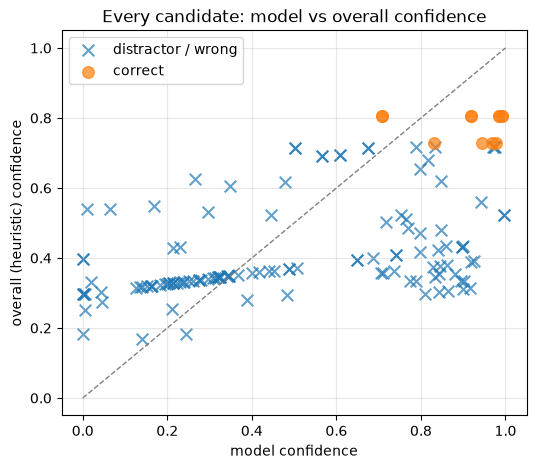

In [12]:
cdf = pd.DataFrame(raw_for_calib)

# (1) Decision-rule accuracy: per image, pick by each rule and check exact match.
rule_rows = []
for p in IMAGES:
    truth = truth_of(p); sub = cdf[cdf.image == p.name]
    if not len(sub): continue
    by_model = sub.loc[sub.model_conf.idxmax(), "digits"]
    by_over  = sub.loc[sub.overall.idxmax(), "digits"]
    cons = next(r["consensus_vote"] for r in ensemble_rows if r["image"] == p.name)
    rule_rows.append(dict(image=p.name, truth=truth,
        pick_by_model_conf=by_model, model_ok=(by_model == truth),
        pick_by_overall=by_over, overall_ok=(by_over == truth),
        consensus_vote=cons, consensus_ok=(cons == truth)))
rdf = pd.DataFrame(rule_rows); display(rdf)
print("exact-match by decision rule:  "
      f"model_conf={rdf.model_ok.mean()*100:.0f}%   overall={rdf.overall_ok.mean()*100:.0f}%   "
      f"consensus={rdf.consensus_ok.mean()*100:.0f}%")

# (2) Confident distractors: high model conf but WRONG -> the heuristic should rate them lower.
cd = cdf[(cdf.model_conf >= 0.55) & (~cdf.correct)].sort_values("model_conf", ascending=False)
print("\nConfident distractors (model_conf>=0.55 but WRONG) — note the heuristic deflates them:")
display(cd[["image","engine","digits","model_conf","overall"]].head(10))

fig, ax = plt.subplots(figsize=(6,5))
for corr, m, lab in [(False,"x","distractor / wrong"),(True,"o","correct")]:
    s = cdf[cdf.correct == corr]
    ax.scatter(s.model_conf, s.overall, marker=m, s=70, alpha=0.7, label=lab)
ax.plot([0,1],[0,1],"--",c="gray",lw=1)
ax.set_xlabel("model confidence"); ax.set_ylabel("overall (heuristic) confidence")
ax.set_title("Every candidate: model vs overall confidence"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## Visual check — predicted account number on each cheque

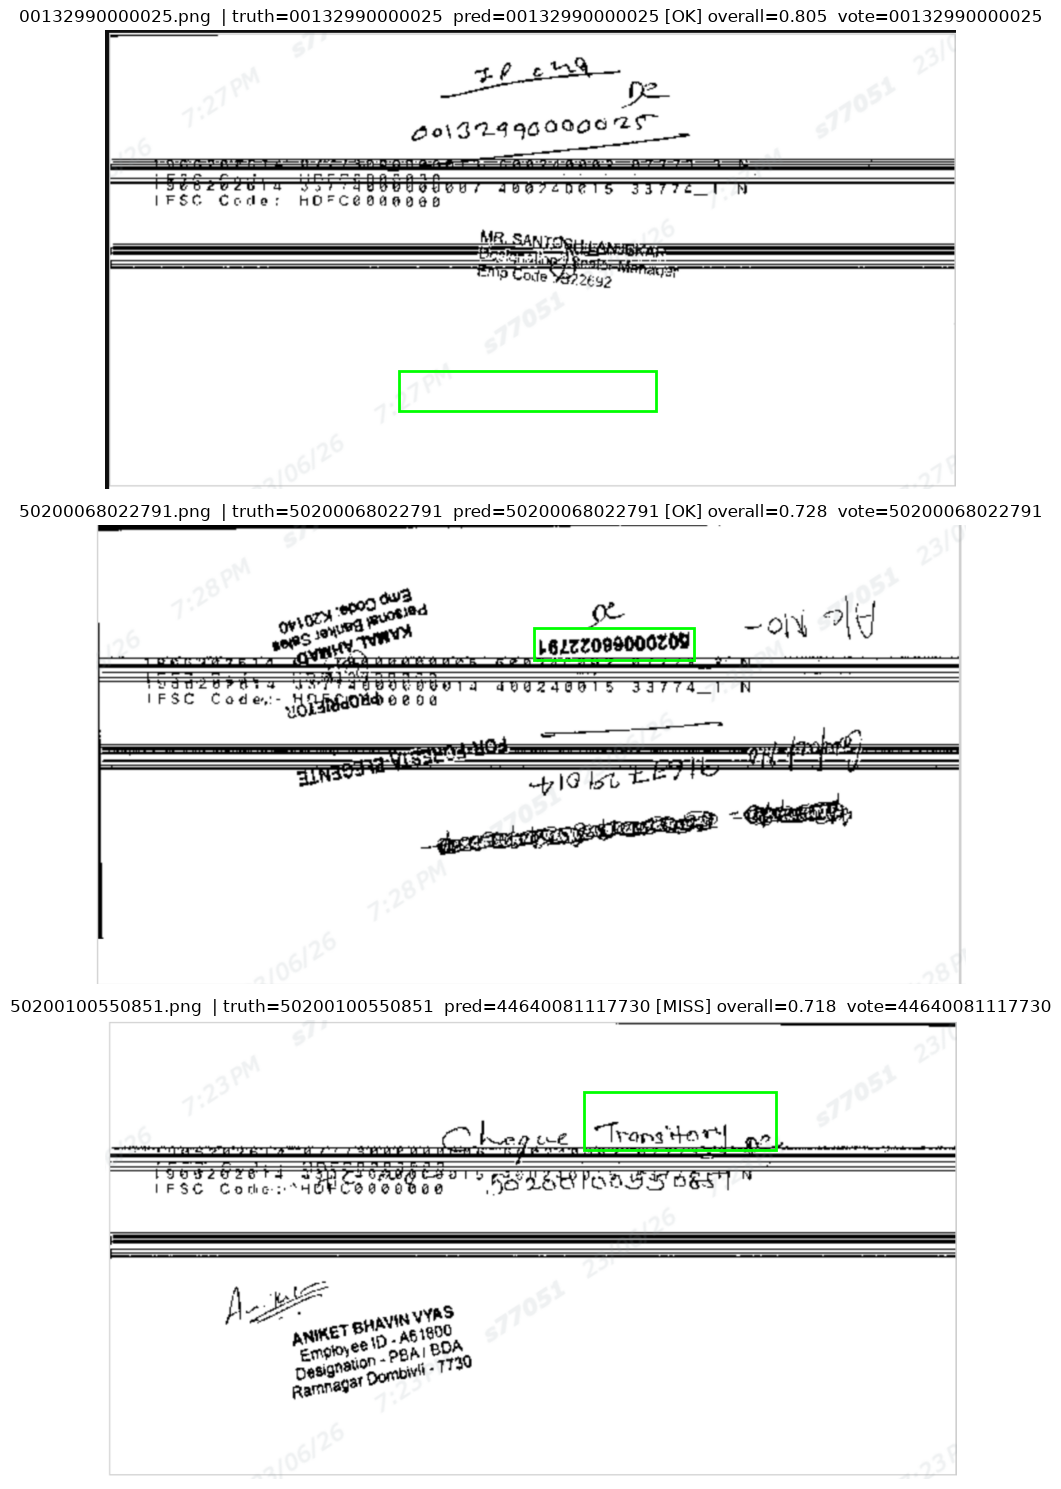

In [13]:
import matplotlib.patches as patches
fig, axes = plt.subplots(len(IMAGES), 1, figsize=(13, 5*len(IMAGES)))
if len(IMAGES) == 1: axes = [axes]
for ax, p in zip(axes, IMAGES):
    img = load_rgb(p); ax.imshow(img)
    row = next(r for r in ensemble_rows if r["image"] == p.name)
    s = all_scored[p.name].get(row["prediction"])
    if s and s["box"] != (0,0,0,0):
        x0,y0,x1,y1 = s["box"]
        ax.add_patch(patches.Rectangle((x0,y0), x1-x0, y1-y0, fill=False, lw=2, edgecolor="lime"))
    ok = "OK" if row["exact"] else "MISS"
    ax.set_title(f"{p.name}  | truth={row['truth']}  pred={row['prediction']} [{ok}] "
                 f"overall={row['overall_conf']}  vote={row['consensus_vote']}")
    ax.axis("off")
plt.tight_layout(); plt.show()

## Summary — engine accuracy, heuristic confidence & which engine to use
Per-engine **exact-match rate** and **mean CER** (accuracy), the engine's own **model confidence** vs our **heuristic (overall) confidence**, and how well the heuristic confidence separates the engine's *correct* reads from its *wrong* ones — alongside speed / weight / offline profile. The recommendation at the bottom is derived from these numbers.

In [ ]:
# Static profile (year / kind / approx CPU speed / weight / torch / offline) merged with measured accuracy.
prof = {
 "ppocrv5":  dict(name="PP-OCRv5",         year=2025, kind="ONNX specialist", torch=False, weight="~16 MB", speed_s=0.6, offline="bundled"),
 "rapidocr": dict(name="RapidOCR/PP-OCRv4",year=2023, kind="ONNX specialist", torch=False, weight="~15 MB", speed_s=1.0, offline="bundled"),
 "tesseract":dict(name="Tesseract",        year=2006, kind="classic CV",      torch=False, weight="system", speed_s=1.0, offline="yes"),
 "easyocr":  dict(name="EasyOCR",          year=2020, kind="CRAFT+CRNN",      torch=True,  weight="~64 MB", speed_s=3.0, offline="cached"),
 "trocr":    dict(name="TrOCR-HW",         year=2021, kind="HW transformer",  torch=True,  weight="~1.4 GB",speed_s=60,  offline="cached"),
 "got":      dict(name="GOT-OCR 2.0",      year=2024, kind="OCR transformer", torch=True,  weight="~1.4 GB",speed_s=18,  offline="cached"),
 "qwen":     dict(name="Qwen2.5-VL-3B",    year=2025, kind="VLM (frontier)",  torch=True,  weight="~7 GB",  speed_s=900, offline="cached"),
}
rows = []
for eng in ENGINES:
    sub = df[df.engine == eng]; cor = sub[sub.exact]; wr = sub[~sub.exact]; p = prof.get(eng, {})
    rows.append(dict(
        engine=p.get("name", eng), year=p.get("year"), kind=p.get("kind"),
        exact_pct=round(sub.exact.mean()*100, 1), mean_CER=round(sub.cer.mean(), 3),
        model_conf=round(sub.model_conf.mean(), 3), heur_conf=round(sub.overall.mean(), 3),
        heur_correct=(round(cor.overall.mean(), 3) if len(cor) else None),
        heur_wrong=(round(wr.overall.mean(), 3) if len(wr) else None),
        sec_img=p.get("speed_s"), weight=p.get("weight"), torch=p.get("torch"), offline=p.get("offline")))
summary = pd.DataFrame(rows).sort_values(["exact_pct", "mean_CER"], ascending=[False, True]).reset_index(drop=True)
print(summary.to_string(index=False))

best = summary.iloc[0]
cpu = summary[~summary.torch].sort_values(["exact_pct", "mean_CER"], ascending=[False, True])
cpu_best = cpu.iloc[0] if len(cpu) else best
ens_acc = round(pd.DataFrame(ensemble_rows).exact.mean()*100, 1)
hc = summary.heur_correct.dropna().mean(); hw = summary.heur_wrong.dropna().mean()
print("\n================ RECOMMENDATION ================")
print(f"- Best accuracy (single engine):  {best.engine}  -> {best.exact_pct}% exact, CER {best.mean_CER}")
print(f"- Best for CPU / offline / no-torch:  {cpu_best.engine}  -> {cpu_best.exact_pct}% exact, "
      f"~{cpu_best.sec_img}s/img, {cpu_best.weight}")
print(f"- Most reliable: ENSEMBLE (heuristic + per-digit consensus) -> {ens_acc}% exact")
print(f"- Heuristic confidence separates correct vs wrong: mean {hc:.2f} (correct) vs {hw:.2f} (wrong)")
print("- VLMs (Qwen-3B): frontier but ~minutes/image on CPU and no better here -> use only with a GPU.")
print("\nPRODUCTION CHOICE: run PP-OCRv5 (primary) + RapidOCR + GOT-OCR2 as a cross-check, take the")
print("per-digit consensus, and gate any result with overall-confidence < 0.60 (or no cross-engine")
print("agreement) to human review. Reserve VLMs for a GPU box / hard rejects.")


           engine  year            kind  exact_pct  mean_CER  model_conf  heur_conf  heur_correct  heur_wrong  sec_img  weight  torch offline
         PP-OCRv5  2025 ONNX specialist       66.7     0.167       0.938      0.612         0.766       0.303      0.6  ~16 MB  False bundled
RapidOCR/PP-OCRv4  2023 ONNX specialist       33.3     0.286       0.756      0.599         0.728       0.535      1.0  ~15 MB  False bundled
    Qwen2.5-VL-3B  2025  VLM (frontier)       33.3     0.595       0.422      0.384         0.805       0.174    900.0   ~7 GB   True  cached
      GOT-OCR 2.0  2024 OCR transformer       33.3     0.667       0.236      0.268         0.805       0.000     18.0 ~1.4 GB   True  cached
          EasyOCR  2020      CRAFT+CRNN        0.0     0.309       0.329      0.537           NaN       0.537      3.0  ~64 MB   True  cached
         TrOCR-HW  2021  HW transformer        0.0     0.333       0.428      0.398           NaN       0.398     60.0 ~1.4 GB   True  cached
      

## Notes & caveats
- **Only 3 images** — this is a smoke test of the *pipeline and the confidence heuristic*, not a
  statistically meaningful accuracy estimate. Don't tune thresholds to these 3.
- **Length prior is configurable** (`ACCT_TARGET_LEN`, `ACCT_MIN/MAX_LEN`) — set it per bank;
  the heuristic does not hard-assume 14 digits beyond the structural score.
- **Offline**: RapidOCR ships models in its wheel; EasyOCR + TrOCR weights are pre-cached, then
  `HF_HUB_OFFLINE=1` keeps everything local. No network at run time.
- **Why model confidence alone is risky** is shown in the calibration cell: a printed-text engine
  can report high confidence on a MICR/garbage number; the heuristic deflates those via structure +
  region + cross-engine/per-digit agreement.
- **Honest limitation observed:** on genuinely hard handwriting, engines rarely agree on the full
  14-digit string, and a **single-digit** handwriting error that the crowd agrees on still earns
  moderate-high confidence — the hardest case to catch without a human check. Treat a high overall
  score as "likely right, still worth a glance," not a guarantee. The strongest single signal here
  is **per-digit consensus**, not any one model's confidence.
- **Practical takeaway:** RapidOCR (ONNX, no torch) was the best lightweight single engine;
  TrOCR helps only on tight handwriting crops; for production, route low-overall-confidence cheques
  to human-in-the-loop review.